## Project 1 NLP Flora Gashi

### Introduction

This project tackles the CommonsenseQA task, a multiple-choice question answering benchmark designed to test a model’s ability to reason using commonsense knowledge. Each question has five answer options, labeled A to E, and only one correct answer. The goal is to train a model that selects the correct answer given the question and options.

The dataset consists of:
- A **question** field (natural language question)
- A list of **five answer choices**
- The correct **answer key** (label A–E)

I applied basic preprocessing: lowercasing, whitespace tokenization, minimal punctuation cleaning, and handled unknown words using FastText subword embeddings.

A common baseline for this task is a random guess, which yields an accuracy of **20%** (1 out of 5). Any model exceeding this threshold demonstrates that it has learned patterns beyond chance. In this project, both implemented models are evaluated against this baseline.

To represent words, I used a pretrained FastText embedding model from Facebook. It provides 300-dimensional word vectors and uses subword information (character n-grams). We discussed in class that FastText generally performs better than Word2Vec or GloVe.    
  - For the MLP, mean-pooled question and answer embeddings are concatenated.  
  - For the RNN, the question and answer are combined into a sequence and embedded token-wise.

I implemented two models:  
  - A **feedforward MLP** with two linear layers  
  - A **GRU-based RNN**, which processes the embedded sequences

Both models were trained using cross-entropy loss and the Adam optimizer. I tuned hyperparameters like learning rate, dropout, and hidden size, and applied early stopping based on validation accuracy. In total I wanted to run 12 experiment per model but because of connection issues (multiple times during training) I couldn't run the last experiment for the GRU model.

The best-performing model (per type) was selected based on validation accuracy and evaluated on the test set. I report overall accuracy, show confusion matrices, and perform error analysis by displaying selected misclassified examples.

[**WandB Project Link**](https://wandb.ai/flora-gashi-hochschule-luzern/commonsense_project_1?nw=nwuserfloragashi)

### Setup

In [4]:
%pip install fasttext
%pip install datasets
%pip install nltk
%pip install lightning
%pip install wandb
%pip install scikit-learn
%pip install torchmetrics
%pip install fasttext huggingface_hub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp311-cp311-linux_x86_64.whl size=4313503 sha256=9cb04a66732e24af05a6640f8acc93b847b93edc84cdaebc182bed380830224c
  Stored in directory: /root/.cache/pip/wheels/65/4f/35/5057db0249224e9ab55a513fa6b79451473ceb7713017823c3
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
%pip install numpy==1.23.5 --force-reinstall


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 20.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
xarray 2025.1.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.23.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have 

In [1]:
%pip install datasets --no-deps --force-reinstall


  Using cached datasets-3.5.0-py3-none-any.whl.metadata (19 kB)
Using cached datasets-3.5.0-py3-none-any.whl (491 kB)
  Attempting uninstall: datasets
    Found existing installation: datasets 3.5.0
    Uninstalling datasets-3.5.0:
      Successfully uninstalled datasets-3.5.0


In [2]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
import re
import numpy as np
import wandb
import random
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from huggingface_hub import hf_hub_download
import fasttext
from collections import defaultdict
import warnings
import glob

In [3]:
model_path = hf_hub_download(repo_id="facebook/fasttext-en-vectors", filename="model.bin")
fast_text_model = fasttext.load_model(model_path)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.bin:   0%|          | 0.00/7.24G [00:00<?, ?B/s]

## Preprocessing

- **Tokenization:** I use simple white-space tokenization (`text.split()` after cleaning). Since FastText uses subword information, it doesn’t need advanced tokenizers like BERT. This kind of tokenization is easy and works well for my case.

- **Lowercasing:** I applied lowercasing during preprocessing to reduce the number of distinct word forms. For example, “Dog” and “dog” refer to the same concept, but would be treated as separate tokens without lowercasing.

- **No stemming/lemmatizing:** I keep the original word forms because FastText can handle inflections using subword units. Lemmatizing might actually remove useful meaning.

- **No stopword/punctuation removal (mostly):** I keep stopwords because commonsense reasoning often depends on small words like "if", "but", or "not". Removing them could hurt performance. I also keep apostrophes (') but remove other punctuation. Apostrophes are important for contractions like "don't", which change sentence meaning. Most other punctuation doesn't contribute meaningful information for embeddings and I removed them to simplify processing.

- **Handling unknown words:** FastText supports subword-based embedding generation even for unknown words (OOV). I use `.get_word_vector(word)` which always returns a vector, even if the word is not in the vocabulary. I did some check for rare words to see if it actually returns a vector. If no valid tokens remain after preprocessing, I return a zero-vector or zero-padded sequence as fallback, to keep input shapes consistent and avoid errors during batching.

- **Format Cleaning:** I checked the dataset for unwanted characters like HTML tags or newlines using SQL queries directly in Hugging Face. The data is already clean and does not need extra processing. I executed following sql-queries for train and validation and got no matches:
```
SELECT * FROM (dataset)
WHERE question LIKE '%<%' OR question LIKE '%>%' OR question LIKE '%&%';
```
```
SELECT * FROM (dataset)
WHERE question ~ '[^a-zA-Z0-9\s\.,?!'']'
```
```
SELECT * FROM (dataset)
WHERE question LIKE '%\n%' OR question LIKE '%\t%'

```

- **Feature Selection:** I use the question text and each of the 5 answer options. These are the inputs the model uses to decide which answer is correct.

- **Input format:**  
  Each question is combined with each answer option to form five input pairs.  
  - For the **MLP**, I compute the mean of the FastText embeddings for the question and answer separately, then concatenate the two vectors → resulting in a 600-dimensional input vector per choice.  
  - For the **RNN**, I concatenate the question and answer into a single text string, tokenize it, and get a sequence of embeddings. Each sequence is passed into a GRU layer. Since sequences vary in length, I apply padding during batch collation.


- **Label Format:** The correct answer is given by a letter (A–E). I convert this to an index (0–4) using ord(label) - ord('A'), so it works with PyTorch's loss functions.


- **Train/Validation/Test splits:**  
  I split the dataset as follows:  
  - **Train:** Most of the original training set  
  - **Validation:** The last 1,000 examples from the train set  
  - **Test:** The provided validation set

- **Batching and padding:**  
  - For the **MLP**, each input is a fixed-size vector (600-dimensional), so batching is trivial.  
  - For the **RNN**, sequences can be of different lengths. I use a custom collate_fn to pad all sequences in a batch to the same maximum length, to make sure of correct tensor shapes: (batch_size, 5, max_len, 300).

- **Summary Embedding strategy for MLP:**  
  I use mean pooling to create fixed-size embeddings. For each question and each answer option, I average the FastText vectors of all known words in the text. This gives me one 300-dimensional vector for the question and one for the answer. Then I concatenate them into a single 600-dimensional vector.  
  Mean pooling works well because it gives a compact summary of the whole sentence and isn’t affected by sentence length. It’s also more informative than just using the first word or summing all vectors.

- **Summary Embedding strategy for RNN:**  
  For the RNN model, I treat the question and each answer option as one combined sequence. I tokenize the full text and convert each token into a FastText vector (if it exists in the model). The result is a sequence of 300-dimensional vectors, one per word.  
  Since different sequences have different lengths, I use padding to make all sequences in a batch the same length. The padded sequences are then passed into a GRU, which processes them one step (word) at a time.

In [4]:
dataset = load_dataset("commonsense_qa")
train = load_dataset("tau/commonsense_qa", split="train[:-1000]")
valid = load_dataset("tau/commonsense_qa", split="train[-1000:]")
test = load_dataset("tau/commonsense_qa", split="validation")

print(len(train), len(valid), len(test))

README.md:   0%|          | 0.00/7.39k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9741 [00:00<?, ? examples/s]

...

test-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9741 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1221 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1140 [00:00<?, ? examples/s]

8741 1000 1221


In [5]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s']", "", text)
    return text.split()

# for classifier
def mean_embedding(tokens, model):
    vectors = [model.get_word_vector(word) for word in tokens]
    if not vectors:
        return np.zeros(model.get_dimension())
    return np.mean(vectors, axis=0)

# for rnn
def sequence_embedding(tokens, model):
    vectors = []
    for word in tokens:
        vec = model.get_word_vector(word)
        vectors.append(torch.tensor(vec, dtype=torch.float32))

    if len(vectors) == 0:
        return torch.zeros((1, 300))

    return torch.stack(vectors)



To load and preprocess the CommonsenseQA data efficiently, I created a custom CommonSenseQADataset class, inspired by PyTorch’s official documentation for working with Dataset and DataLoader.
This class allows me to handle both MLP and RNN input formats in a unified way. It processes each sample by taking the question and all five answer choices and returns either concatenated mean-pooled embeddings (for MLP) or sequences of word embeddings (for the RNN).

In [6]:
class CommonSenseQADataset(Dataset):
    def __init__(self, data, model, mode="mlp"):
        self.data = data
        self.model = model
        self.mode = mode

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
          try:
              item = self.data[idx]
              question = item["question"]
              choices = item["choices"]["text"]
              label_str = item["answerKey"]
              label_idx = ord(label_str) - ord("A")
          except Exception as e:
              warnings.warn(f"Skipping bad sample at index {idx}: {e}")
              return None

          inputs = []
          for choice in choices:
              if self.mode == "mlp":
                  # for mlp: mean pooled embeddings
                  q_vec = mean_embedding(preprocess_text(question), self.model)
                  a_vec = mean_embedding(preprocess_text(choice), self.model)
                  combined = np.concatenate([q_vec, a_vec])
                  inputs.append(torch.tensor(combined, dtype=torch.float32))
              elif self.mode == "rnn":
                  # for rnn: sequence input
                  combined_text = question + " " + choice
                  tokens = preprocess_text(combined_text)
                  seq = sequence_embedding(tokens, self.model)
                  inputs.append(seq)  # shape (max_len, 300)

          if self.mode == "mlp":
              # output is tensor of shape (5, 600)
              return torch.stack(inputs), torch.tensor(label_idx)
          elif self.mode == "rnn":
              # list of tensor
              return inputs, label_idx

I implemented the collate_fn_rnn function to dynamically pad all sequences in a batch to the same length.


In [7]:
def collate_fn_rnn(batch):
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return None

    try:
        input_lists, labels = zip(*batch)
    except Exception as e:
        return None

    max_len = max(seq.shape[0] for sample in input_lists for seq in sample)

    batch_inputs = []
    for sample in input_lists:  # each sample has 5 choices (sequences)
        padded_choices = []
        for seq in sample:
            seq_tensor = seq
            if seq_tensor.size(0) < max_len:
                pad_len = max_len - seq_tensor.size(0)
                padding = torch.zeros(pad_len, seq_tensor.size(1))  # shape: (pad_len, 300)
                seq_tensor = torch.cat([seq_tensor, padding], dim=0)  # now (max_len, 300)

            padded_choices.append(seq_tensor)  # 5 x (max_len, 300)

        # stack into shape: (5, max_len, 300)
        sample_tensor = torch.stack(padded_choices)
        batch_inputs.append(sample_tensor)

    # final batch: (batch_size, 5, max_len, 300)
    batch_tensor = torch.stack(batch_inputs)
    label_tensor = torch.tensor(labels)

    return batch_tensor, label_tensor


In [8]:
def get_dataloader(split, model, mode="mlp", batch_size=32, shuffle=False, collate_fn=None):
    dataset = CommonSenseQADataset(split, model, mode=mode)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

### Correctness Tests

In [9]:
dl = get_dataloader(train, fast_text_model, mode="rnn", batch_size=4, collate_fn=collate_fn_rnn)
xb, yb = next(iter(dl))
print(xb.shape)
print(yb.shape)


torch.Size([4, 5, 24, 300])
torch.Size([4])


In [10]:
tokens = ["this", "is", "a", "test"]
vec = mean_embedding(tokens, fast_text_model)

assert isinstance(vec, np.ndarray)
assert vec.shape == (300,)
assert not np.isnan(vec).any()
print("mean_embedding() works correctly")

mean_embedding() works correctly


In [11]:
tokens = ["school", "is", "great"]
vecs = sequence_embedding(tokens, fast_text_model)

assert isinstance(vecs, torch.Tensor)
assert vecs.shape[1] == 300
print("sequence_embedding() returns tensor of shape (seq_len, 300)")


sequence_embedding() returns tensor of shape (seq_len, 300)


In [12]:
dataset = CommonSenseQADataset(train, fast_text_model, mode="mlp")
x, y = dataset[0]

assert isinstance(x, torch.Tensor)
assert x.shape == (5, 600)
assert isinstance(y, torch.Tensor)
print("MLP sample shape and label correct")


MLP sample shape and label correct


In [13]:
dataset = CommonSenseQADataset(train, fast_text_model, mode="rnn")
seqs, y = dataset[0]

assert isinstance(seqs, list)
assert len(seqs) == 5
assert all(isinstance(seq, torch.Tensor) for seq in seqs)
assert all(seq.dim() == 2 and seq.shape[1] == 300 for seq in seqs)

print("RNN sample returns 5 sequences, each as (seq_len, 300) tensor")


RNN sample returns 5 sequences, each as (seq_len, 300) tensor


In [14]:
small_sample = train.select(range(8))
rnn_dataset = CommonSenseQADataset(small_sample, fast_text_model, mode="rnn")

loader = DataLoader(rnn_dataset, batch_size=4, collate_fn=collate_fn_rnn)

x_batch, y_batch = next(iter(loader))

assert isinstance(x_batch, torch.Tensor)
assert x_batch.shape[0] == 4
assert x_batch.shape[1] == 5
assert x_batch.shape[3] == 300
print("collate_fn_rnn batching and padding works")

collate_fn_rnn batching and padding works


In [15]:
# all sequences in batch same length
seq_lens = [x_batch[i, j].shape[0] for i in range(x_batch.shape[0]) for j in range(5)]
assert len(set(seq_lens)) == 1, "Padding failed: not all sequences have same length"
print("All sequences padded to same length")


All sequences padded to same length


In [ ]:
def check_sample_format(item):
    if not isinstance(item, dict): return False
    if "question" not in item or "choices" not in item or "answerKey" not in item: return False
    if len(item["choices"]["text"]) != 5: return False
    return True

valid_samples = [item for item in train if check_sample_format(item)]
print(f"Valid entries: {len(valid_samples)} / {len(train)}")


Valid entries: 8741 / 8741


In [16]:
print("badarse" in fast_text_model)
print(fast_text_model["badarse"][:5])

print("calligrapher's" in fast_text_model)
print(fast_text_model["calligrapher's"][:5])


True
[ 0.03743899 -0.04256555  0.00252121  0.06980162 -0.04380747]
False
[-8.0018220e-03 -4.5202363e-05 -9.2268698e-03  5.3644344e-02
 -1.6367748e-02]


# Models


### MLP
Since my MLP model works with fixed-size inputs, I use mean-pooled embeddings for the question and each of the 5 answer options.
Each of the 5 question-answer pairs is processed independently by the model, using a small feedforward neural network with one hidden layer and ReLU activation.

**Overview:**

- Input: (B, 5, 600) → B = batch size, 5 answer choices, 600 features per choice  
- The model reshapes this to (B×5, 600), feeds it through the MLP, and reshapes the output back to (B, 5)
- The model outputs one scalar (logit) per answer choice
- This should be compatible with `CrossEntropyLoss` which expects logits for multiple classes


In [17]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=600, hidden_dim=128, output_dim=1, dropout=0.3):
        super(MLPClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        B, C, D = x.shape  # B x 5 x 600
        x = x.view(B * C, D)
        logits = self.classifier(x)  # (B*5, 1)
        logits = logits.view(B, C)   # (B, 5)
        return logits


### RNN: GRU Classifier

For my RNN-based model, I use a GRU instead of an LSTM. GRUs are generally simpler, faster to train, and use fewer parameters, which is ideal for smaller datasets like CommonsenseQA. In this task, sequences are relatively short (question + answer), so the additional complexity of LSTMs is not necessary in my opinion.

The input to the model is a batch of question–answer sequences, embedded with FastText vectors. Each sample has 5 answer options, so the input shape is:

**(batch_size, 5, seq_len, 300)**

For each of the 5 answer choices:
- The question and answer are combined into a single sequence.
- The GRU processes the sequence and returns the final hidden state.
- A classifier maps that state to a single scalar logit.

The model outputs a score for each answer choice:

**Output shape: (batch_size, 5)** → one logit per answer option, ready for `CrossEntropyLoss`.


In [18]:
class GRUClassifier(nn.Module):
    def __init__(self, embedding_dim=300, hidden_dim=128, output_dim=1, num_layers=2, dropout=0.3, bidirectional=False):
        super(GRUClassifier, self).__init__()
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        final_dim = hidden_dim * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Linear(final_dim, final_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(final_dim, output_dim)
        )

    def forward(self, x):
        B = x.size(0)
        all_logits = []

        for i in range(5):
            seq = x[:, i, :, :]  # B x seq_len x 300
            _, h_n = self.gru(seq)
            if self.bidirectional:
                h_final = torch.cat((h_n[-2], h_n[-1]), dim=1)
            else:
                h_final = h_n[-1]  # B x hidden

            logit = self.classifier(h_final)  # B x 1
            all_logits.append(logit.squeeze(-1))  # B

        return torch.stack(all_logits, dim=1)


# Training Strategy
I use CrossEntropyLoss, which is the standard loss for multi-class classification problems where only one class is correct. Each question has one correct answer out of five choices, so this loss is a good fit.

For optimization, I use the Adam optimizer. It is widely used in NLP because it adapts the learning rate for each parameter. I also apply weight decay (L2 regularization) to prevent overfitting.

To explore the performance of the two models under different conditions, I use the following hyperparameters:
- **Learning Rate:** 1e-3, 1e-4, 1e-5
→ To test different convergence speeds and robustness.
- **Dropout:** 0.1, 0.3
→ To investigate regularization strength. Lower dropout retains more information, while higher dropout can prevent overfitting on small datasets.
- **Hidden Dimension:** 128, 256
→ To evaluate whether a larger representation helps, and whether bigger models generalize better or worse.
- **Batch Size:** 128
- **Weight Decay:** 1e-5
- **Number of epochs:** 40
- **Patience for Early Stopping:** 12

Each model is trained with all combinations of these values (3 LRs × 2 Dropouts × 2 Hiddens = 12 runs per model). I keep the **batch size** constant with size of 128 (biggest possible size for memory).




### Early Stopping
Each run is allowed to train for up to 40 epochs, but I use early stopping with a patience of 12 epochs. I chose these values so I can give the models enough time to learn, while also preventing unnecessary overfitting or over-computation.

The value 12 should be a good balance: it allows short plateaus during training but avoids wasting time when no improvement happens for many epochs.

### Model Checkpointing
Whenever validation accuracy improves, I save the model to disk using torch.save. It makes sure that I can later reload the best model (not just the final one) for evaluation on the test set or for error analysis.

### Number of Runs
So in total I run 12 configurations for the MLP and do the same for the GRU (for last training run it would always crash so 11 experiments in the end).

Each configuration is fully trained with fixed seed (42) for reproducibility. This allows me to compare both architectures fairly and observe if there are any trends across hyperparameters.

In [19]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [20]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    skipped_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            if batch is None:
                skipped_batches += 1
                continue

            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total if total > 0 else 0.0
    avg_loss = total_loss / (len(dataloader) - skipped_batches) if (len(dataloader) - skipped_batches) > 0 else 0.0
    return acc, avg_loss


In [22]:
def train_model(model, train_loader, val_loader, config, device):
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
    )
    loss_fn = nn.CrossEntropyLoss()
    best_val_acc = 0
    patience_counter = 0
    model = model.to(device)

    for epoch in range(config["epochs"]):
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0
        skipped_batches = 0

        for batch in train_loader:
            if batch is None:
                skipped_batches += 1
                continue

            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(x_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct_train += (preds == y_batch).sum().item()
            total_train += y_batch.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train if total_train > 0 else 0.0

        val_acc, val_loss = evaluate(model, val_loader, loss_fn, device)

        wandb.log({
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "skipped_batches": skipped_batches
        }, step=epoch + 1)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Val Loss={val_loss:.4f} | Skipped: {skipped_batches}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            fname = f"{config['model_type']}_lr{config['lr']}_do{config['dropout']}_hd{config['hidden_dim']}_bs{config['batch_size']}.pt"
            torch.save(model.state_dict(), fname)
            wandb.save(fname)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config["patience"]:
                print("Early stopping triggered")
                break

    return best_val_acc


### Training with hyperparameters (grid method)

In [23]:
param_grid = {
    "lr": [1e-3, 1e-4, 1e-5],
    "dropout": [0.1, 0.3],
    "hidden_dim": [128, 256],
    "batch_size": [16],
    "weight_decay": [1e-5],
    "epochs": [40],
    "patience": [12],
    "seed": [42]
}

param_combinations = list(itertools.product(
    param_grid["lr"],
    param_grid["dropout"],
    param_grid["hidden_dim"]
))

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def run_experiment(model_type, lr, dropout, hidden_dim, seed, batch_size, weight_decay, epochs, patience):
    config = {
        "model_type": model_type,
        "lr": lr,
        "dropout": dropout,
        "hidden_dim": hidden_dim,
        "seed": seed,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
        "epochs": epochs,
        "patience": patience
    }

    wandb.init(
        project="commonsense_project_1",
        name=f"{model_type}_lr{lr}_do{dropout}_hd{hidden_dim}_bs{batch_size}",
        config=config
    )

    set_seed(seed)

    if model_type == "mlp":
        model = MLPClassifier(hidden_dim=hidden_dim, dropout=dropout)
        collate_fn = None
    elif model_type == "gru":
        model = GRUClassifier(hidden_dim=hidden_dim, dropout=dropout)
        collate_fn = collate_fn_rnn
    else:
        raise ValueError("Unknown model type")

    data_mode = "rnn" if model_type == "gru" else "mlp"
    train_loader = get_dataloader(train, fast_text_model, mode=data_mode, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = get_dataloader(valid, fast_text_model, mode=data_mode, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    print(f"\n Training {model_type.upper()} | LR: {lr} | DO: {dropout} | HD: {hidden_dim} | BS: {batch_size}")
    best_acc = train_model(model, train_loader, val_loader, config, device)

    fname = f"{model_type}_lr{lr}_do{dropout}_hd{hidden_dim}_bs{batch_size}.pt"
    torch.save(model.state_dict(), fname)

    wandb.run.summary["best_val_acc"] = best_acc
    wandb.finish()


In [ ]:
for model_type in ["mlp", "gru"]:
    for lr, dropout, hidden_dim in param_combinations:
        run_experiment(
            model_type=model_type,
            lr=lr,
            dropout=dropout,
            hidden_dim=hidden_dim,
            seed=42,
            batch_size=128,
            weight_decay=1e-5,
            epochs=40,
            patience=12
        )

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: flora-gashi (flora-gashi-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

[DEBUG] model_type = gru
[DEBUG] Using collate_fn = collate_fn_rnn

 Training GRU | LR: 1e-05 | DO: 0.1 | HD: 128 | BS: 128
Epoch 1: Train Loss=1.6094 | Train Acc=0.2114 | Val Acc=0.1850 | Val Loss=1.6094 | Skipped: 0
Epoch 2: Train Loss=1.6095 | Train Acc=0.1967 | Val Acc=0.1870 | Val Loss=1.6094 | Skipped: 0
Epoch 3: Train Loss=1.6095 | Train Acc=0.1941 | Val Acc=0.1910 | Val Loss=1.6094 | Skipped: 0
Epoch 4: Train Loss=1.6094 | Train Acc=0.2049 | Val Acc=0.1930 | Val Loss=1.6094 | Skipped: 0
Epoch 5: Train Loss=1.6094 | Train Acc=0.2028 | Val Acc=0.1920 | Val Loss=1.6094 | Skipped: 0
Epoch 6: Train Loss=1.6094 | Train Acc=0.2012 | Val Acc=0.1910 | Val Loss=1.6094 | Skipped: 0
Epoch 7: Train Loss=1.6095 | Train Acc=0.2036 | Val Acc=0.1880 | Val Loss=1.6094 | Skipped: 0
Epoch 8: Train Loss=1.6095 | Train Acc=0.1984 | Val Acc=0.1900 | Val Loss=1.6094 | Skipped: 0
Epoch 9: Train Loss=1.6095 | Train Acc=0.1944 | Val Acc=0.1930 | Val Loss=1.6094 | Skipped: 0
Epoch 10: Train Loss=1.6094 | 

skipped_batches,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▇▂▁▅▄▄▅▃▁▅▃▂▃▄▃▄▅▅▂▂▆█▁▂▂▅▄
train_loss,▃▇▇▄▃▄▆▇▆▅▅▃▆▄▃▆▄▂▅▄▂▁█▇▇▃▅
val_accuracy,▄▅▆▇▆▆▅▆▇▆█▇▅██▄▇▃▃▁▂▂▄▁▅▂▄
val_loss,██▇▇▅▆▆▇▇▇▆▆▅▄▅▆▇▄▆▆▆▆▃▅▂▂▁
best_val_acc,0.197
skipped_batches,0
train_accuracy,0.20204
train_loss,1.60945
val_accuracy,0.186
val_loss,1.60943


[DEBUG] model_type = gru
[DEBUG] Using collate_fn = collate_fn_rnn

 Training GRU | LR: 1e-05 | DO: 0.1 | HD: 256 | BS: 128
Epoch 1: Train Loss=1.6094 | Train Acc=0.2097 | Val Acc=0.1790 | Val Loss=1.6094 | Skipped: 0
Epoch 2: Train Loss=1.6095 | Train Acc=0.1989 | Val Acc=0.2000 | Val Loss=1.6094 | Skipped: 0
Epoch 3: Train Loss=1.6094 | Train Acc=0.2003 | Val Acc=0.1880 | Val Loss=1.6094 | Skipped: 0
Epoch 4: Train Loss=1.6095 | Train Acc=0.1961 | Val Acc=0.1850 | Val Loss=1.6094 | Skipped: 0
Epoch 5: Train Loss=1.6093 | Train Acc=0.2034 | Val Acc=0.1900 | Val Loss=1.6094 | Skipped: 0
Epoch 6: Train Loss=1.6095 | Train Acc=0.1965 | Val Acc=0.1880 | Val Loss=1.6094 | Skipped: 0
Epoch 7: Train Loss=1.6094 | Train Acc=0.2018 | Val Acc=0.1890 | Val Loss=1.6094 | Skipped: 0
Epoch 8: Train Loss=1.6095 | Train Acc=0.1976 | Val Acc=0.1960 | Val Loss=1.6094 | Skipped: 0
Epoch 9: Train Loss=1.6095 | Train Acc=0.2040 | Val Acc=0.1810 | Val Loss=1.6094 | Skipped: 0
Epoch 10: Train Loss=1.6094 | 

skipped_batches,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,█▂▃▁▅▁▄▂▅▄▁▃▂▃
train_loss,▅▇▅█▁▇▄▇▆▄██▅▅
val_accuracy,▁█▄▃▅▄▄▇▂▆▄▃▅▆
val_loss,█▇▆▅▄▄▄▅▄▃▂▁▁▁
best_val_acc,0.2
skipped_batches,0
train_accuracy,0.20043
train_loss,1.60944
val_accuracy,0.194
val_loss,1.60944


[DEBUG] model_type = gru
[DEBUG] Using collate_fn = collate_fn_rnn

 Training GRU | LR: 1e-05 | DO: 0.3 | HD: 128 | BS: 128
Epoch 1: Train Loss=1.6095 | Train Acc=0.2032 | Val Acc=0.1770 | Val Loss=1.6094 | Skipped: 0
Epoch 2: Train Loss=1.6099 | Train Acc=0.1940 | Val Acc=0.1960 | Val Loss=1.6094 | Skipped: 0


# Evaluation

### Metrics
**Accuracy**: the primary metric I report. Since each question in CommonSenseQA has exactly one correct answer out of five, accuracy directly reflects how often the model chooses the correct option.

**Confusion Matrix**: I include a confusion matrix to visualize which answer choices the model most often confuses with others. Although the class labels (A–E) are arbitrary and not semantically meaningful, the matrix still provides insight into systematic prediction errors.

### Error Analysis
To understand the models mistakes, I'm analyzing: The confusion matrix, to identify which answer choices are commonly confused with others.
Concrete examples of incorrect predictions: For each model, I print 10 test samples where the model made a wrong prediction.
Each sample includes the question, choices, correct answer, and predicted answer. I also analyzed examples where both models disagreed and at least one was wrong, to compare their errors directly.  
Additionally, I examined accuracy based on the first word of each question to see if certain question types are harder to answer.


### Objective Description of Results
I focus only on reporting what the metrics and outputs show:
The analysis is grounded in quantitative evaluation (scores, matrix) and qualitative samples (wrong predictions).

### Model Selection
Each model (MLP and GRU) was trained using 12 hyperparameter combinations.
I selected the best-performing model based on validation accuracy during training.
The best model was automatically saved using PyTorch's torch.save() whenever validation accuracy improved.
After training, I evaluated the saved model on the test set using the corresponding .pt checkpoint file.

In [27]:
model_files = glob.glob("*.pt")
for f in model_files:
    print(f)


mlp_lr0.001_do0.3_hd256_bs128.pt
gru_lr0.001_do0.1_hd256_bs128.pt


In [35]:
def evaluate_on_test(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            if batch is None:
                continue
            x_batch, y_batch = batch
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return all_preds, all_labels

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="plasma", xticklabels=list("ABCDE"), yticklabels=list("ABCDE"), cbar=True)

    for t in ax.texts:
        val = int(t.get_text())
        t.set_color("black" if val > 50 else "white")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [36]:
def evaluate_model_on_test(model_type, model_path, hidden_dim, dropout, batch_size=128):
    print(f"\n--- Evaluating {model_type.upper()} model ---")

    if model_type == "mlp":
        model = MLPClassifier(hidden_dim=hidden_dim, dropout=dropout)
        collate_fn = None
        mode = "mlp"
    elif model_type == "gru":
        model = GRUClassifier(hidden_dim=hidden_dim, dropout=dropout)
        collate_fn = collate_fn_rnn
        mode = "rnn"
    else:
        raise ValueError("Unknown model type")

    model.load_state_dict(torch.load(model_path))
    model.to(device)

    test_loader = get_dataloader(test, fast_text_model, mode=mode, batch_size=batch_size, collate_fn=collate_fn)

    preds, labels = evaluate_on_test(model, test_loader, device)

    test_acc = accuracy_score(labels, preds)
    print(f"\nTest Accuracy for {model_type.upper()}: {test_acc:.4f}\n")

    plot_conf_matrix(labels, preds, title=f"{model_type.upper()} Confusion Matrix")

    wrong_indices = [i for i, (p, l) in enumerate(zip(preds, labels)) if p != l]
    print(f"\nExamples of incorrect predictions for {model_type.upper()}:")
    for i in wrong_indices[:10]:
        print(f"Q: {test[i]['question']}")
        print(f"Choices: {test[i]['choices']['text']}")
        print(f"True: {test[i]['answerKey']} | Predicted: {chr(ord('A') + preds[i])}")
        print("-" * 60)

    return preds, labels


### MLP


--- Evaluating MLP model ---

Test Accuracy for MLP: 0.2686



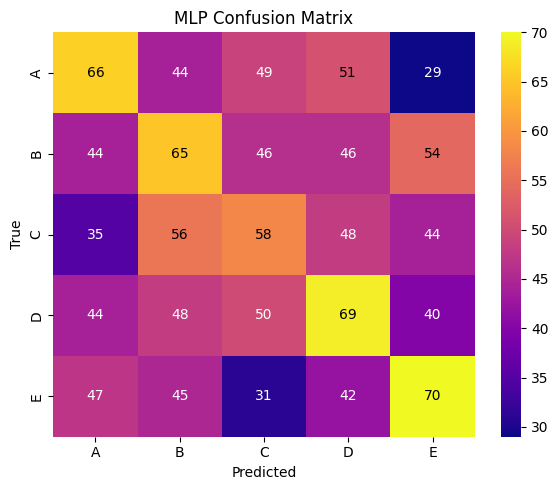


Examples of incorrect predictions for MLP:
Q: What do people aim to do at work?
Choices: ['complete job', 'learn from each other', 'kill animals', 'wear hats', 'talk to each other']
True: A | Predicted: C
------------------------------------------------------------
Q: Where would you find magazines along side many other printed works?
Choices: ['doctor', 'bookstore', 'market', 'train station', 'mortuary']
True: B | Predicted: C
------------------------------------------------------------
Q: James was looking for a good place to buy farmland.  Where might he look?
Choices: ['midwest', 'countryside', 'estate', 'farming areas', 'illinois']
True: A | Predicted: C
------------------------------------------------------------
Q: What do animals do when an enemy is approaching?
Choices: ['feel pleasure', 'procreate', 'pass water', 'listen to each other', 'sing']
True: D | Predicted: C
------------------------------------------------------------
Q: What do people typically do while playing gui

In [43]:
mlp_preds, mlp_labels = evaluate_model_on_test(
    model_type="mlp",
    model_path="mlp_lr0.001_do0.3_hd256_bs128.pt",
    hidden_dim=256,
    dropout=0.3
)

### RNN/GRU


--- Evaluating GRU model ---

Test Accuracy for GRU: 0.2367



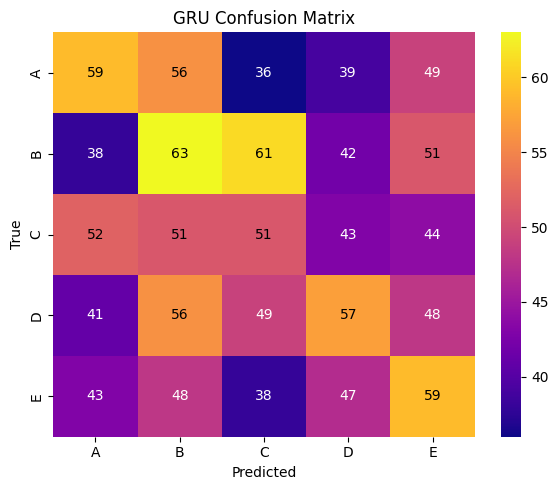


Examples of incorrect predictions for GRU:
Q: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?
Choices: ['bank', 'library', 'department store', 'mall', 'new york']
True: A | Predicted: B
------------------------------------------------------------
Q: What do people aim to do at work?
Choices: ['complete job', 'learn from each other', 'kill animals', 'wear hats', 'talk to each other']
True: A | Predicted: B
------------------------------------------------------------
Q: Where would you find magazines along side many other printed works?
Choices: ['doctor', 'bookstore', 'market', 'train station', 'mortuary']
True: B | Predicted: A
------------------------------------------------------------
Q: Where are  you likely to find a hamburger?
Choices: ['fast food restaurant', 'pizza', 'ground up dead cows', 'mouth', 'cow carcus']
True: A | Predicted: D
------------------------------------------------------------
Q: James was looking f

In [44]:
gru_preds, gru_labels = evaluate_model_on_test(
    model_type="gru",
    model_path="gru_lr0.001_do0.1_hd256_bs128.pt",
    hidden_dim=256,
    dropout=0.1
)

In [45]:
assert len(mlp_preds) == len(gru_preds) == len(mlp_labels)


In [46]:
def compare_model_errors(dataset, preds_mlp, preds_gru, labels, n=5):
    print(f"\nShowing cases where models disagreed and at least one was wrong:\n")

    for i in range(len(labels)):
        if preds_mlp[i] != preds_gru[i] and (preds_mlp[i] != labels[i] or preds_gru[i] != labels[i]):
            item = dataset[i]
            print(f"Q: {item['question']}")
            print(f"Choices: {item['choices']['text']}")
            print(f"Correct: {chr(labels[i]+65)} | MLP: {chr(preds_mlp[i]+65)} | GRU: {chr(preds_gru[i]+65)}\n")
            n -= 1
            if n == 0:
                break


In [48]:
compare_model_errors(test, mlp_preds, gru_preds, mlp_labels, n=20)


Showing cases where models disagreed and at least one was wrong:

Q: A revolving door is convenient for two direction travel, but it also serves as a security measure at a what?
Choices: ['bank', 'library', 'department store', 'mall', 'new york']
Correct: A | MLP: A | GRU: B

Q: What do people aim to do at work?
Choices: ['complete job', 'learn from each other', 'kill animals', 'wear hats', 'talk to each other']
Correct: A | MLP: C | GRU: B

Q: Where would you find magazines along side many other printed works?
Choices: ['doctor', 'bookstore', 'market', 'train station', 'mortuary']
Correct: B | MLP: C | GRU: A

Q: Where are  you likely to find a hamburger?
Choices: ['fast food restaurant', 'pizza', 'ground up dead cows', 'mouth', 'cow carcus']
Correct: A | MLP: A | GRU: D

Q: What island country is ferret popular?
Choices: ['own home', 'north carolina', 'great britain', 'hutch', 'outdoors']
Correct: C | MLP: C | GRU: B

Q: In what Spanish speaking North American country can you get a 

In [49]:
def question_prefix_analysis(dataset, preds, labels, top_k=5):
    groups = defaultdict(list)

    for i, item in enumerate(dataset):
        question = item["question"]
        prefix = question.strip().lower().split()[0]
        correct = int(preds[i] == labels[i])
        groups[prefix].append(correct)

    print(f"\nTop-{top_k} most common question types and their accuracy:\n")
    sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))[:top_k]

    for prefix, results in sorted_groups:
        acc = sum(results) / len(results)
        print(f"{prefix.upper():<10} | Count: {len(results):<4} | Accuracy: {acc:.2f}")


In [50]:
print("=== Question Prefix Accuracy (MLP) ===")
question_prefix_analysis(test, mlp_preds, mlp_labels)

print("\n=== Question Prefix Accuracy (GRU) ===")
question_prefix_analysis(test, gru_preds, gru_labels)


=== Question Prefix Accuracy (MLP) ===

Top-5 most common question types and their accuracy:

WHAT       | Count: 279  | Accuracy: 0.25
WHERE      | Count: 215  | Accuracy: 0.33
THE        | Count: 143  | Accuracy: 0.28
IF         | Count: 93   | Accuracy: 0.28
WHEN       | Count: 36   | Accuracy: 0.14

=== Question Prefix Accuracy (GRU) ===

Top-5 most common question types and their accuracy:

WHAT       | Count: 279  | Accuracy: 0.21
WHERE      | Count: 215  | Accuracy: 0.30
THE        | Count: 143  | Accuracy: 0.25
IF         | Count: 93   | Accuracy: 0.20
WHEN       | Count: 36   | Accuracy: 0.22


### Results (Objective)
Test Accuracy:
- **MLP:** 26.9%
- **GRU:** 23.7%

Both models perform slightly above random guessing (which was 20%), but still far from human-level performance.

Confusion Matrix:
Both confusion matrices (MLP and GRU) show no strong diagonal dominance, which means:
- The models are not reliably predicting the correct class
- Predictions are distributed fairly evenly across all classes

Incorrect Predictions: Some wrong answers are not completely unreasonable. The model often confuses answers that are similar in meaning
- True: "complete job" → Predicted: "kill animals", both involve actions with outcomes
- True: "make peace" → Predicted: "make noise", both share structure and action format ("make X"), but have different intent and it could confuse the model.

Some incorrect choices are actually quite reasonable. Even for a human, choosing the correct answer might require detailed context or common sense knowledge.
- "Where would you find magazines?" → True: bookstore vs. Predicted: market,  both are plausible

**Comparative Error Insights of both models:**
In a small set of 20 examples where the MLP and GRU models gave different answers and at least one of them was wrong, many of the mistakes were caused by answer choices that were still reasonable. Often, the wrong answers were similar in meaning or context to the correct ones, which might have confused the model. Overall, neither model clearly performed better than the other in these cases, they just made different kinds of mistakes.

**Question Type Analysis:**
To better understand where the models struggle, I analyzed accuracy based on the first word (prefix) of each question.

- **"WHERE" questions** had the highest accuracy for both models (MLP: 33%, GRU: 30%).
- **"WHEN" questions** performed the worst (MLP: 14%, GRU: 22%), possibly because they require understanding of time or events, which is harder to capture with word embeddings alone.
- **"WHAT" was the most common question type**, but its accuracy was only moderate (MLP: 25%, GRU: 21%).

## Tools/References used
[Understanding FastText](https://ayselaydin.medium.com/13-understanding-fasttext-efficient-word-representations-for-nlp-fbb5ecae352e)

ChatGPT was used for:
 - helping with grammar/misspelled words in markdown
 - error handling with right input to model. I initially used the tensors in a wrong way and did some debugging with ChatGPT to make sure my input was correct for my RNN model.
 - I had None values in batches when training my RNN, ChatGPT helped me figure out that I used my collate_fn_rnn function at the wrong place in my code.
